# 📊 Sales Analytics EDA

Исследование данных интернет-магазина.

Цели анализа:

- оценить динамику продаж
- определить наиболее прибыльные товары
- проанализировать клиентов
- найти закономерности поведения покупателей
- сформировать бизнес-выводы

In [3]:
import pandas as pd


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [1]:
import os

os.getcwd()

'/Users/macbookair/Developer/sales-analytics-platform/notebooks'

In [4]:
customers = pd.read_csv("../data/customers.csv")
orders = pd.read_csv("../data/orders.csv")
products = pd.read_csv("../data/products.csv")
order_items = pd.read_csv("../data/order_items.csv")

In [5]:
customers.head()

,customer_id,name,city,registration_date
0,1,Mrs. Heather Kelley,Санкт-Петербург,2025-09-14
1,2,Thomas Walker,Екатеринбург,2024-03-02
2,3,Jonathan Harrison,Новосибирск,2026-01-01
3,4,Lucas Ross,Ростов-на-Дону,2024-01-15
4,5,Janice Erickson,Москва,2025-02-07


In [6]:
orders.head()

,order_id,customer_id,order_date,status,amount
0,1,7464,2026-07-10,completed,97194
1,2,6187,2026-07-18,completed,50797
2,3,1418,2024-09-03,cancelled,26243
3,4,2890,2025-12-10,cancelled,76564
4,5,2399,2025-01-02,cancelled,34601


In [7]:
products.head()

,product_id,product_name,category,price
0,1,American,Красота,45279
1,2,Day,Спорт,27398
2,3,Difference,Спорт,37528
3,4,Card,Дом,13809
4,5,Sense,Красота,12339


In [8]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Products:", products.shape)
print("Order items:", order_items.shape)

Customers: (10000, 4)
Orders: (50000, 5)
Products: (500, 4)
Order items: (149874, 3)


In [9]:
customers.info()
orders.info()
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   customer_id        10000 non-null  int64
 1   name               10000 non-null  str  
 2   city               10000 non-null  str  
 3   registration_date  10000 non-null  str  
dtypes: int64(1), str(3)
memory usage: 731.3 KB
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   order_id     50000 non-null  int64
 1   customer_id  50000 non-null  int64
 2   order_date   50000 non-null  str  
 3   status       50000 non-null  str  
 4   amount       50000 non-null  int64
dtypes: int64(3), str(2)
memory usage: 2.8 MB
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        ----

In [10]:
print("Customers missing values:")
display(customers.isna().sum())

print("Orders missing values:")
display(orders.isna().sum())

print("Products missing values:")
display(products.isna().sum())

print("Order items missing values:")
display(order_items.isna().sum())

Customers missing values:


customer_id          0
name                 0
city                 0
registration_date    0
dtype: int64

Orders missing values:


order_id       0
customer_id    0
order_date     0
status         0
amount         0
dtype: int64

Products missing values:


product_id      0
product_name    1
category        0
price           0
dtype: int64

Order items missing values:


order_id      0
product_id    0
quantity      0
dtype: int64

In [11]:
sales = orders.merge(
    order_items,
    on="order_id",
    how="inner"
)

sales.head()

,order_id,customer_id,order_date,status,amount,product_id,quantity
0,1,7464,2026-07-10,completed,97194,371,2
1,1,7464,2026-07-10,completed,97194,393,2
2,2,6187,2026-07-18,completed,50797,47,1
3,2,6187,2026-07-18,completed,50797,130,2
4,2,6187,2026-07-18,completed,50797,154,1


In [12]:
sales = sales.merge(
    products,
    on="product_id",
    how="left"
)

sales.head()

,order_id,customer_id,order_date,status,amount,product_id,quantity,product_name,category,price
0,1,7464,2026-07-10,completed,97194,371,2,Popular,Электроника,1949
1,1,7464,2026-07-10,completed,97194,393,2,Occur,Электроника,1789
2,2,6187,2026-07-18,completed,50797,47,1,Position,Одежда,35214
3,2,6187,2026-07-18,completed,50797,130,2,Authority,Дом,46424
4,2,6187,2026-07-18,completed,50797,154,1,Size,Электроника,5803


In [13]:
sales["revenue"] = sales["quantity"] * sales["price"]

sales.head()

,order_id,customer_id,order_date,status,amount,product_id,quantity,product_name,category,price,revenue
0,1,7464,2026-07-10,completed,97194,371,2,Popular,Электроника,1949,3898
1,1,7464,2026-07-10,completed,97194,393,2,Occur,Электроника,1789,3578
2,2,6187,2026-07-18,completed,50797,47,1,Position,Одежда,35214,35214
3,2,6187,2026-07-18,completed,50797,130,2,Authority,Дом,46424,92848
4,2,6187,2026-07-18,completed,50797,154,1,Size,Электроника,5803,5803


In [14]:
total_revenue = sales["revenue"].sum()

total_orders = orders["order_id"].nunique()

average_order_value = total_revenue / total_orders


print(f"Revenue: {total_revenue:,.2f}")
print(f"Orders: {total_orders}")
print(f"AOV: {average_order_value:,.2f}")

Revenue: 7,560,858,566.00
Orders: 50000
AOV: 151,217.17


In [15]:
kpi = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Average Order Value"
    ],
    "Value": [
        total_revenue,
        total_orders,
        average_order_value
    ]
})

kpi

,Metric,Value
0,Total Revenue,7.560859e+09
1,Total Orders,5.000000e+04
2,Average Order Value,1.512172e+05


In [16]:
orders.head()

,order_id,customer_id,order_date,status,amount
0,1,7464,2026-07-10,completed,97194
1,2,6187,2026-07-18,completed,50797
2,3,1418,2024-09-03,cancelled,26243
3,4,2890,2025-12-10,cancelled,76564
4,5,2399,2025-01-02,cancelled,34601


In [18]:
orders.columns

Index(['order_id', 'customer_id', 'order_date', 'status', 'amount'], dtype='str')

In [19]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

orders.head()

,order_id,customer_id,order_date,status,amount
0,1,7464,2026-07-10,completed,97194
1,2,6187,2026-07-18,completed,50797
2,3,1418,2024-09-03,cancelled,26243
3,4,2890,2025-12-10,cancelled,76564
4,5,2399,2025-01-02,cancelled,34601


In [20]:
sales = sales.merge(
    orders[["order_id", "order_date"]],
    on="order_id",
    how="left"
)

sales.head()

,order_id,customer_id,order_date_x,status,amount,product_id,quantity,product_name,category,price,revenue,order_date_y
0,1,7464,2026-07-10,completed,97194,371,2,Popular,Электроника,1949,3898,2026-07-10
1,1,7464,2026-07-10,completed,97194,393,2,Occur,Электроника,1789,3578,2026-07-10
2,2,6187,2026-07-18,completed,50797,47,1,Position,Одежда,35214,35214,2026-07-18
3,2,6187,2026-07-18,completed,50797,130,2,Authority,Дом,46424,92848,2026-07-18
4,2,6187,2026-07-18,completed,50797,154,1,Size,Электроника,5803,5803,2026-07-18


In [23]:
sales = sales.drop(columns=["order_date_y"])

In [24]:
sales = sales.rename(
    columns={"order_date_x": "order_date"}
)

sales.head()

,order_id,customer_id,order_date,status,amount,product_id,quantity,product_name,category,price,revenue
0,1,7464,2026-07-10,completed,97194,371,2,Popular,Электроника,1949,3898
1,1,7464,2026-07-10,completed,97194,393,2,Occur,Электроника,1789,3578
2,2,6187,2026-07-18,completed,50797,47,1,Position,Одежда,35214,35214
3,2,6187,2026-07-18,completed,50797,130,2,Authority,Дом,46424,92848
4,2,6187,2026-07-18,completed,50797,154,1,Size,Электроника,5803,5803


In [25]:
sales["order_date"] = pd.to_datetime(sales["order_date"])

sales["month"] = sales["order_date"].dt.to_period("M").astype(str)

sales.head()

,order_id,customer_id,order_date,status,amount,product_id,quantity,product_name,category,price,revenue,month
0,1,7464,2026-07-10,completed,97194,371,2,Popular,Электроника,1949,3898,2026-07
1,1,7464,2026-07-10,completed,97194,393,2,Occur,Электроника,1789,3578,2026-07
2,2,6187,2026-07-18,completed,50797,47,1,Position,Одежда,35214,35214,2026-07
3,2,6187,2026-07-18,completed,50797,130,2,Authority,Дом,46424,92848,2026-07
4,2,6187,2026-07-18,completed,50797,154,1,Size,Электроника,5803,5803,2026-07


In [26]:
monthly_sales = (
    sales
    .groupby("month")["revenue"]
    .sum()
    .reset_index()
)

monthly_sales

,month,revenue
0,2024-07,86750280
1,2024-08,311809434
2,2024-09,301033588
3,2024-10,331124310
4,2024-11,316413814
5,2024-12,319499112
6,2025-01,309521056
7,2025-02,291850669
8,2025-03,318394875
9,2025-04,313598884


In [27]:
monthly_sales


,month,revenue
0,2024-07,86750280
1,2024-08,311809434
2,2024-09,301033588
3,2024-10,331124310
4,2024-11,316413814
5,2024-12,319499112
6,2025-01,309521056
7,2025-02,291850669
8,2025-03,318394875
9,2025-04,313598884


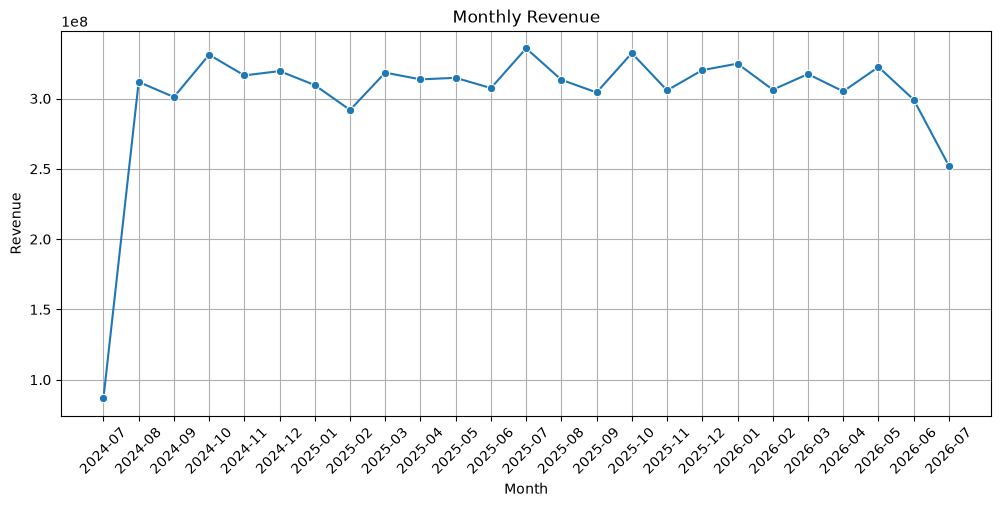

In [28]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_sales,
    x="month",
    y="revenue",
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

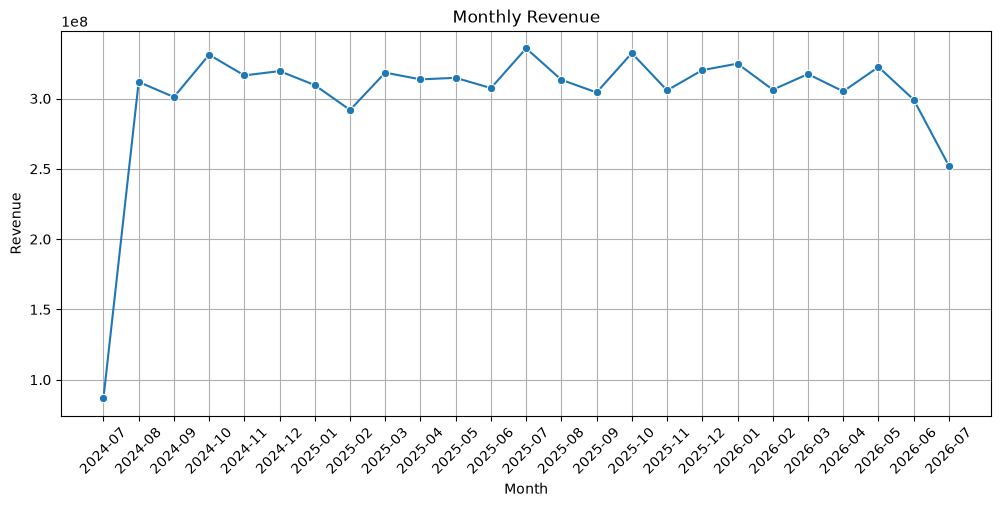

In [29]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_sales,
    x="month",
    y="revenue",
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(True)

plt.savefig(
    "../images/monthly_revenue.png",
    bbox_inches="tight"
)

plt.show()

In [30]:
top_products = (
    sales
    .groupby(["product_name", "category"])["revenue"]
    .sum()
    .reset_index()
    .sort_values(
        "revenue",
        ascending=False
    )
)

top_products.head(10)

,product_name,category,revenue
6,Affect,Спорт,49028949
274,Old,Спорт,46049270
313,Put,Дом,44068903
344,Rock,Книги,42897220
221,Law,Красота,38791533
122,Effect,Электроника,38063570
32,Bar,Красота,36307414
323,Reduce,Одежда,35205504
65,Century,Книги,33959958
262,Next,Красота,32089370


In [31]:
top10_products = top_products.head(10)

top10_products

,product_name,category,revenue
6,Affect,Спорт,49028949
274,Old,Спорт,46049270
313,Put,Дом,44068903
344,Rock,Книги,42897220
221,Law,Красота,38791533
122,Effect,Электроника,38063570
32,Bar,Красота,36307414
323,Reduce,Одежда,35205504
65,Century,Книги,33959958
262,Next,Красота,32089370


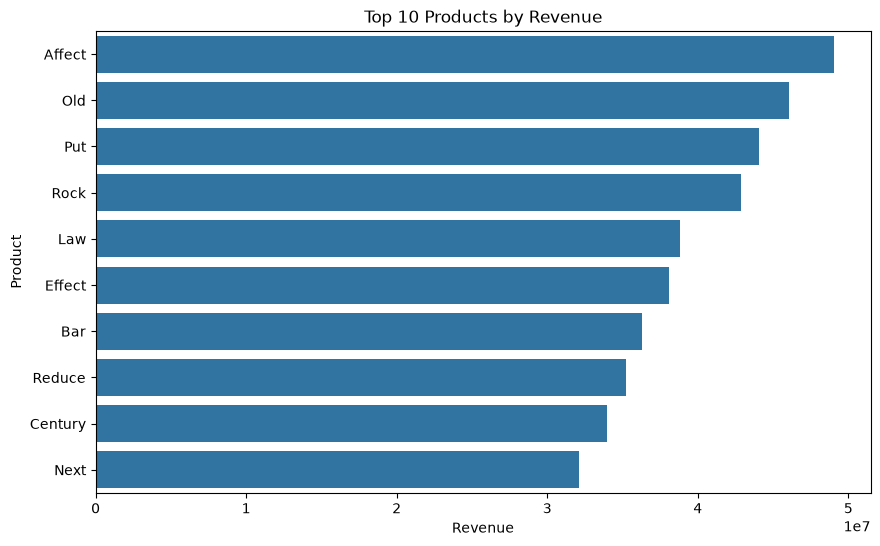

In [32]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top10_products,
    x="revenue",
    y="product_name"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.show()

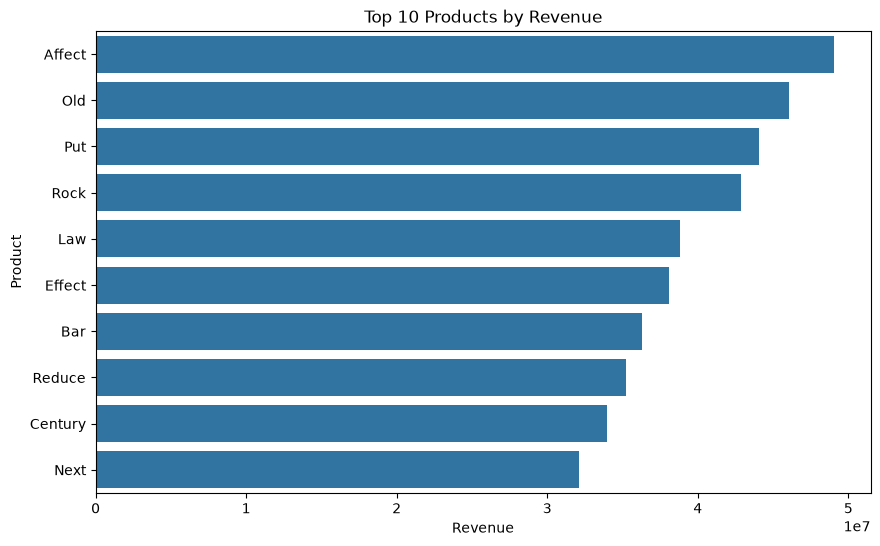

In [33]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top10_products,
    x="revenue",
    y="product_name"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.savefig(
    "../images/top_products.png",
    bbox_inches="tight"
)

plt.show()

In [34]:
customer_sales = (
    sales
    .groupby("customer_id")["revenue"]
    .sum()
    .reset_index()
    .sort_values(
        "revenue",
        ascending=False
    )
)

customer_sales.head(10)

,customer_id,revenue
53,54,2446795
9490,9563,2426472
6954,7015,2426025
1662,1681,2424971
1654,1673,2399329
4194,4232,2379253
7472,7536,2361684
1205,1219,2343062
7409,7473,2328727
3644,3676,2328388


In [35]:
top_customers = customer_sales.head(10)

top_customers

,customer_id,revenue
53,54,2446795
9490,9563,2426472
6954,7015,2426025
1662,1681,2424971
1654,1673,2399329
4194,4232,2379253
7472,7536,2361684
1205,1219,2343062
7409,7473,2328727
3644,3676,2328388


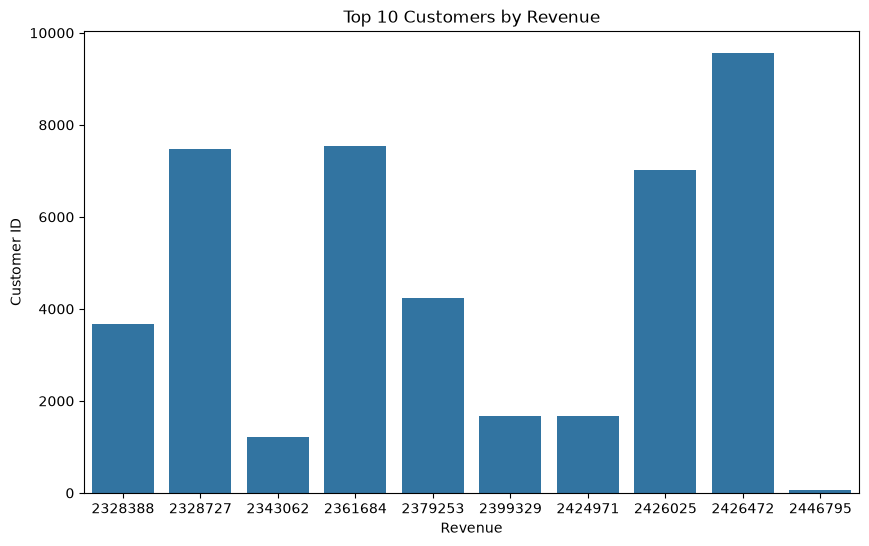

In [36]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_customers,
    x="revenue",
    y="customer_id"
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

plt.show()

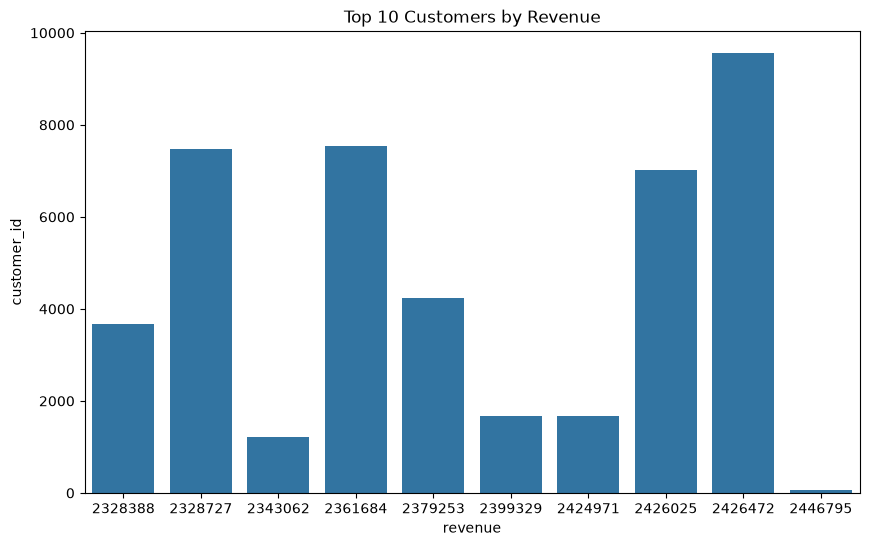

In [37]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_customers,
    x="revenue",
    y="customer_id"
)

plt.title("Top 10 Customers by Revenue")

plt.savefig(
    "../images/top_customers.png",
    bbox_inches="tight"
)

plt.show()

In [38]:
customer_metrics = (
    sales
    .groupby("customer_id")
    .agg(
        orders_count=("order_id", "nunique"),
        total_revenue=("revenue", "sum"),
        average_order_value=("revenue", "mean")
    )
    .reset_index()
)

customer_metrics.head()

,customer_id,orders_count,total_revenue,average_order_value
0,1,7,1123499,46812.458333
1,2,2,245755,35107.857143
2,3,6,836195,46455.277778
3,4,2,216862,54215.500000
4,5,6,1208867,63624.578947


In [39]:
customer_metrics.describe()

,customer_id,orders_count,total_revenue,average_order_value
count,9926.000000,9926.000000,9.926000e+03,9926.000000
mean,5005.443180,5.037276,7.617226e+05,50416.874846
std,2887.377976,2.205928,3.956789e+05,11305.935014
min,1.000000,1.000000,8.287000e+03,6211.750000
25%,2507.250000,3.000000,4.707328e+05,43482.276786
50%,5008.500000,5.000000,7.151630e+05,50050.222222
75%,7507.750000,6.000000,1.016581e+06,56878.505981
max,10000.000000,17.000000,2.446795e+06,135282.000000


In [40]:
sales["order_date"] = pd.to_datetime(sales["order_date"])

sales["customer_id"].nunique()

9926

In [41]:
analysis_date = sales["order_date"].max()

analysis_date

Timestamp('2026-07-24 00:00:00')

In [42]:
rfm = (
    sales
    .groupby("customer_id")
    .agg(
        Recency=(
            "order_date",
            lambda x: (analysis_date - x.max()).days
        ),
        Frequency=(
            "order_id",
            "nunique"
        ),
        Monetary=(
            "revenue",
            "sum"
        )
    )
    .reset_index()
)

rfm.head()

,customer_id,Recency,Frequency,Monetary
0,1,88,7,1123499
1,2,310,2,245755
2,3,254,6,836195
3,4,32,2,216862
4,5,362,6,1208867


In [43]:
rfm["R_score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

rfm["F_score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

rfm["M_score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score
0,1,88,7,1123499,3,4,5
1,2,310,2,245755,1,1,1
2,3,254,6,836195,1,4,4
3,4,32,2,216862,4,1,1
4,5,362,6,1208867,1,4,5


In [44]:
rfm["RFM_Score"] = (
    rfm["R_score"].astype(str)
    +
    rfm["F_score"].astype(str)
    +
    rfm["M_score"].astype(str)
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,1,88,7,1123499,3,4,5,345
1,2,310,2,245755,1,1,1,111
2,3,254,6,836195,1,4,4,144
3,4,32,2,216862,4,1,1,411
4,5,362,6,1208867,1,4,5,145


In [45]:
def segment(row):
    if row["R_score"] >= 4 and row["F_score"] >= 4:
        return "Champions"
    
    elif row["R_score"] >= 3 and row["F_score"] >= 3:
        return "Loyal Customers"
    
    elif row["R_score"] <= 2:
        return "At Risk"
    
    else:
        return "Regular"


rfm["Segment"] = rfm.apply(segment, axis=1)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
0,1,88,7,1123499,3,4,5,345,Loyal Customers
1,2,310,2,245755,1,1,1,111,At Risk
2,3,254,6,836195,1,4,4,144,At Risk
3,4,32,2,216862,4,1,1,411,Regular
4,5,362,6,1208867,1,4,5,145,At Risk
